In [58]:
pip install pandas numpy scikit-learn nltk streamlit jupyter matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
# Import required libraries
import pandas as pd
import numpy as np
import re
import nltk

# Download stopwords (used in NLP cleaning)
nltk.download('stopwords')
from nltk.corpus import stopwords

# For stemming
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to C:\Users\HP Z
[nltk_data]     Book\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [60]:
# Load datasets
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Add labels (0 = Fake, 1 = Real)
fake['label'] = 0
true['label'] = 1

# Combine datasets
df = pd.concat([fake, true])

# Shuffle dataset
df = df.sample(frac=1).reset_index(drop=True)

# Show data
df.head()

,title,text,subject,date,label
0,Buddhist mistrust of foreign aid workers hampe...,"SITTWE, Myanmar (Reuters) - Relief agencies st...",worldnews,"September 23, 2017",1
1,Trump's continued search for new FBI chief see...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"June 2, 2017",1
2,GERMANY CRISIS ESCALATES: Muslim Migrants Mast...,What a great place to take the whole family!We...,left-news,"Jan 22, 2016",0
3,Senate panel chair says will hold hearings on ...,WASHINGTON (Reuters) - Republican U.S. Senator...,politicsNews,"July 18, 2017",1
4,Christian Extremists In Oregon Launch Campaig...,Christian extremists in Oregon are dragging th...,News,"January 13, 2016",0


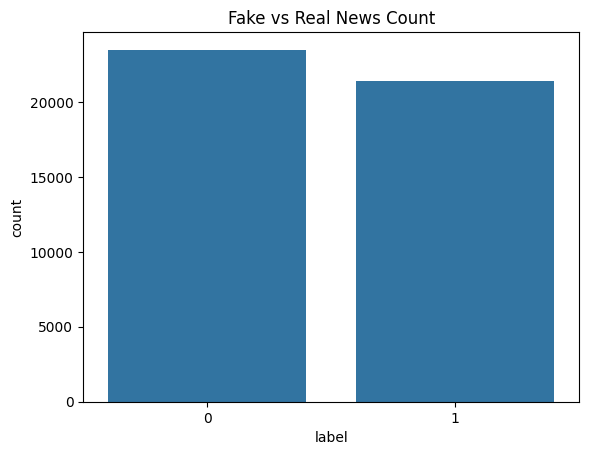

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=df)
plt.title("Fake vs Real News Count")
plt.show()

In [62]:
# Remove missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

In [63]:
df = df.head(2000)

In [64]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['text'] = df['text'].apply(clean_text)

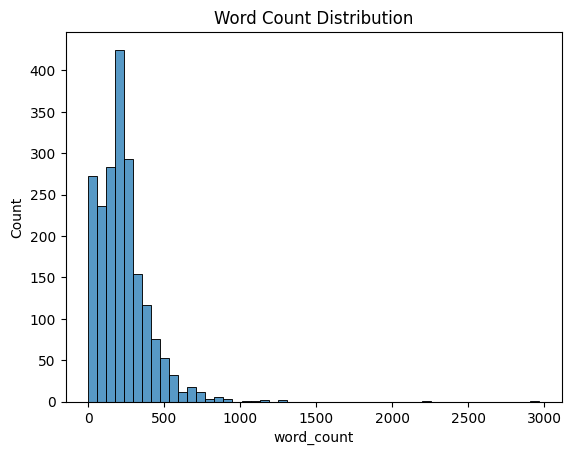

In [73]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into numerical features
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['text']).toarray()
y = df['label']

In [66]:
from sklearn.model_selection import train_test_split

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create models dictionary
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.955
Naive Bayes Accuracy: 0.9175
SVM Accuracy: 0.9675
Random Forest Accuracy: 0.9825


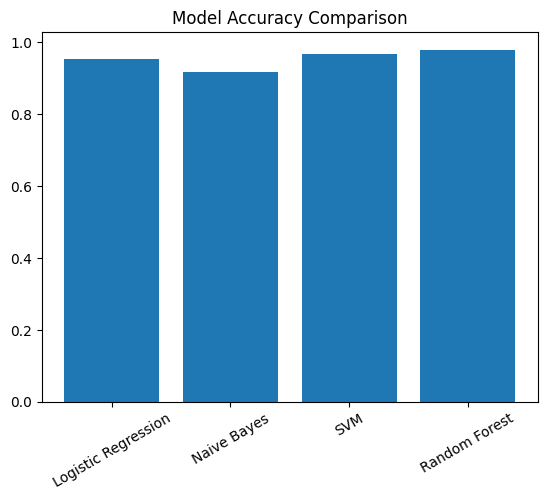

In [74]:
model_names = []
accuracies = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    model_names.append(name)
    accuracies.append(acc)

plt.bar(model_names, accuracies)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

In [68]:
# Using Logistic Regression as final model (example)
final_model = LogisticRegression()
final_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [69]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = final_model.predict(X_test)

# Print evaluation metrics
print(classification_report(y_test, y_pred))

# Confusion matrix
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       212
           1       0.97      0.94      0.95       188

    accuracy                           0.95       400
   macro avg       0.96      0.95      0.95       400
weighted avg       0.96      0.95      0.95       400

[[206   6]
 [ 12 176]]


In [70]:
def predict_news(text):
    text = clean_text(text)
    text = vectorizer.transform([text]).toarray()
    result = final_model.predict(text)

    if result[0] == 1:
        return "Real News"
    else:
        return "Fake News"

In [71]:
print(predict_news("India wins cricket world cup"))
print(predict_news("Aliens landed in Delhi yesterday"))

Fake News
Fake News


In [72]:
import pickle

# Save trained model and vectorizer
pickle.dump(final_model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

